### 1 : Importing Libraries

In [1]:
# ignore the warnings in the output
import warnings
warnings.filterwarnings("ignore")

In [2]:
# import libraries and packages
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import mlflow
from pycaret.classification import *
import sqlite3
from sqlite3 import Error

 ### 2 Reading Data

In [3]:
%%time
##Copy the cleaned data obtained from the data_cleaning notebook into the Data folder before proceeding
dataset = pd.read_csv('data/cleaned_data.csv')

CPU times: user 362 ms, sys: 60.3 ms, total: 422 ms
Wall time: 420 ms


In [4]:
dataset.head()

,created_date,city_tier,first_platform_c,first_utm_medium_c,first_utm_source_c,total_leads_droppped,referred_lead,app_complete_flag,assistance_interaction,career_interaction,payment_interaction,social_interaction,syllabus_interaction
0,2021-07-01 00:08:15,1.0,Level0,Level11,Level2,1.0,0.0,1,0.0,0.0,0.0,0.0,0.0
1,2021-07-01 00:16:43,2.0,Level3,Level0,others,1.0,0.0,1,0.0,0.0,0.0,0.0,0.0
2,2021-07-01 00:22:20,1.0,Level3,Level0,Level0,1.0,0.0,1,0.0,0.0,0.0,0.0,0.0
3,2021-07-01 00:23:13,1.0,Level1,Level3,others,2.0,0.0,0,0.0,0.0,0.0,0.0,0.0
4,2021-07-01 00:28:38,1.0,Level3,Level0,Level0,1.0,0.0,0,0.0,0.0,0.0,0.0,0.0


In [5]:
# drop the data column as it is not needed for training
dataset = dataset.drop(['created_date'], axis=1)

### 3 Setting up Environment: 

In [6]:
# Creating database path
database_dir = './'
database_file = 'lead_scoring_model_experimentation.db'
# function to create a connection to the sqlite database at database_dir
def create_sqlit_connection(db_path,db_file):
    """ 
    Description - create a database connection to a SQLite database 
    Input = database path , database file
    output = None
    """
    conn = None
    # creating a connection the sqlite db
    try:
        conn = sqlite3.connect(db_path+db_file)
        print(sqlite3.version) # print the version of sqlite
    except Error as e:
        print(e)
    finally:
        if conn:
            conn.close()
            
# Creating connection to database
create_sqlit_connection(database_dir,database_file)

2.6.0


In [ ]:
# create a mlflow tracking uri at "http://0.0.0.0:6006"
mlflow.set_tracking_uri("http://0.0.0.0:6007")

In [8]:
# setup pycaret 
Baseline_model_exp_01 = setup(data = dataset, target = 'app_complete_flag', 
                   session_id = 42,fix_imbalance=False,
                   n_jobs=-1,use_gpu=True,
                   log_experiment=True,experiment_name='Baseline_model_exp_01',
                   log_plots=True, log_data=True,
                   verbose=True,log_profile=False)

[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] Number of positive: 1, number of negative: 1
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 2, number of used features: 0
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce GTX 1070 Ti, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 16 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Warning] GPU acceleration is disabled because no non-trivial dense features can be found
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that 

,Description,Value
0,Session id,42
1,Target,app_complete_flag
2,Target type,Binary
3,Original data shape,"(238964, 12)"
4,Transformed data shape,"(238964, 44)"
5,Transformed train set shape,"(167274, 44)"
6,Transformed test set shape,"(71690, 44)"
7,Numeric features,8
8,Categorical features,3
9,Preprocess,True


[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] Number of positive: 1, number of negative: 1
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 2, number of used features: 0
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce GTX 1070 Ti, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 16 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Warning] GPU acceleration is disabled because no non-trivial dense features can be found
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that 

### 4 : Model Experimentation with pycaret

In [9]:
# create a experimentation with pycaret and exclude ['gbc','knn','qda', 'dummy', 'svm', 'ada']
best_model = compare_models(fold = 5, exclude= ['gbc','knn','qda', 'dummy', 'svm', 'ada'])

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.7384,0.8203,0.8329,0.7018,0.7617,0.4765,0.4851,2.3300
rf,Random Forest Classifier,0.7376,0.8177,0.8212,0.7048,0.7585,0.4748,0.4815,8.2980
et,Extra Trees Classifier,0.7368,0.8167,0.8185,0.7049,0.7575,0.4733,0.4797,9.6640
dt,Decision Tree Classifier,0.7366,0.8159,0.8180,0.7048,0.7572,0.4729,0.4792,1.2600
lr,Logistic Regression,0.7092,0.7827,0.8184,0.6730,0.7386,0.4179,0.4281,11.5120
lda,Linear Discriminant Analysis,0.7001,0.7725,0.7959,0.6693,0.7271,0.3997,0.4071,2.0880
ridge,Ridge Classifier,0.6997,0.0000,0.7949,0.6692,0.7266,0.3990,0.4063,1.0640
nb,Naive Bayes,0.6655,0.7335,0.8603,0.6211,0.7207,0.3299,0.3600,0.9380


In [10]:
# create a model which gives the highest accuracy
lgbm  = create_model('lightgbm', fold = 5) 

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7419,0.8215,0.8384,0.7040,0.7653,0.4834,0.4925
1,0.7380,0.8212,0.8276,0.7031,0.7603,0.4756,0.4833
2,0.7376,0.8202,0.8338,0.7006,0.7614,0.4749,0.4838
3,0.7371,0.8185,0.8281,0.7019,0.7598,0.4739,0.4818
4,0.7375,0.8203,0.8364,0.6995,0.7619,0.4746,0.4841
Mean,0.7384,0.8203,0.8329,0.7018,0.7617,0.4765,0.4851
Std,0.0017,0.0010,0.0043,0.0016,0.0019,0.0035,0.0038


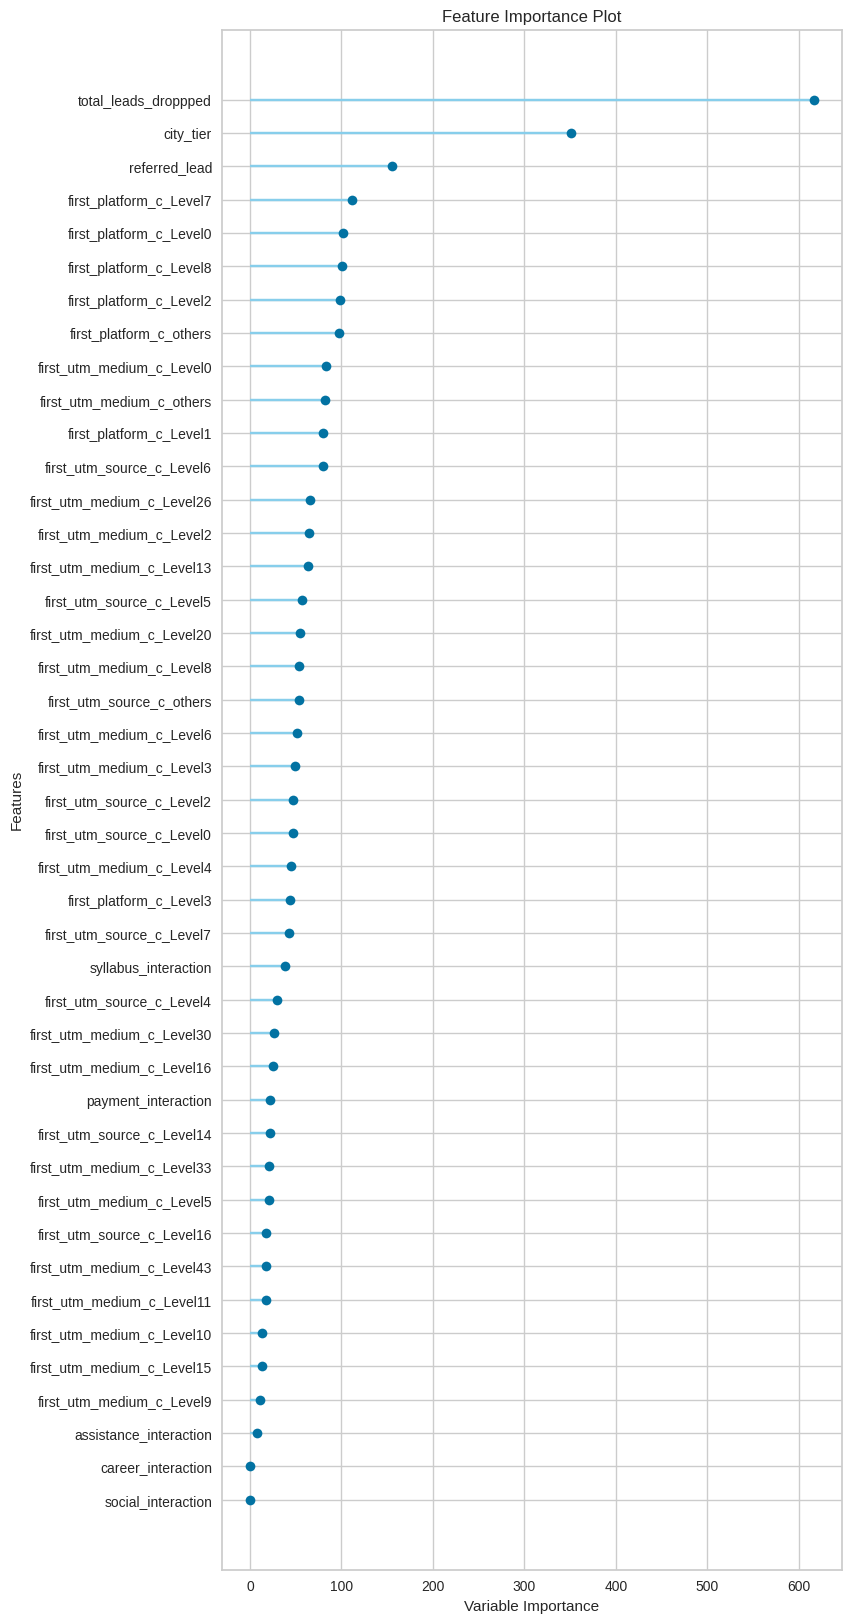

In [11]:
# create feature importance plot
plot_model(lgbm, plot='feature_all')

### 5 : Model Experimentation after dropping features

From the above feature tests we can claerly see that some of the features are not significant. We will now drop all the insignificant features and select only the significant ones.
The list of the significant features is 
['total_leads_droppped', 'city_tier', 'referred_lead', 'app_complete_flag', 'first_platform_c', 'first_utm_medium_c', 'first_utm_source_c'].
So now you will train your model with onlly these features.

Also note that in our previous experiments we saw that tree based models are our top performers. In case of tree based models we do not require transformationss normalization, scaling etc. So make sure that you use setup pycaret in the proper way. i.e, make sure that you use normalize = False and transformation = False.

In [12]:
# ['total_leads_droppped', 'city_tier', 'referred_lead', 'app_complete_flag', 'first_platform_c', 'first_utm_medium_c', 'first_utm_source_c']
final_dataset = dataset[['total_leads_droppped', 'city_tier', 'referred_lead', 'app_complete_flag', 'first_platform_c', 'first_utm_medium_c', 'first_utm_source_c']]

# Train the model using the features listed above. Since we are using tree models we do not require any transformaions 
# such as normalization, scaling etc.So make sure that you use setup pycaret in the proper way. i.e, make sure that you use 
# normalize = False and transformation = False.
Baseline_model_exp_02 = setup(data = final_dataset, target = 'app_complete_flag', 
                   session_id = 42,fix_imbalance=False,
                   n_jobs=-1,use_gpu=True,
                   log_plots=True, log_data=True,
                   verbose=True,log_profile=False,
                   log_experiment=True,experiment_name='Baseline_model_exp_02',
                   normalize = False ,  transformation = False)

[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] Number of positive: 1, number of negative: 1
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 2, number of used features: 0
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce GTX 1070 Ti, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 16 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Warning] GPU acceleration is disabled because no non-trivial dense features can be found
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that 

,Description,Value
0,Session id,42
1,Target,app_complete_flag
2,Target type,Binary
3,Original data shape,"(238964, 7)"
4,Transformed data shape,"(238964, 39)"
5,Transformed train set shape,"(167274, 39)"
6,Transformed test set shape,"(71690, 39)"
7,Numeric features,3
8,Categorical features,3
9,Preprocess,True


[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] Number of positive: 1, number of negative: 1
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 2, number of used features: 0
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce GTX 1070 Ti, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 16 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Warning] GPU acceleration is disabled because no non-trivial dense features can be found
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that 

In [13]:
# create a experimentation with pycaret and exclude ['gbc','knn','qda', 'dummy', 'svm', 'ada']. 
best_model = compare_models(fold = 5, exclude= ['gbc','knn','qda', 'dummy', 'svm', 'ada'])

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.7385,0.8202,0.8333,0.7018,0.7619,0.4767,0.4854,2.5760
rf,Random Forest Classifier,0.7375,0.8177,0.8212,0.7047,0.7585,0.4746,0.4813,7.7380
et,Extra Trees Classifier,0.7369,0.8167,0.8188,0.7049,0.7575,0.4734,0.4798,9.5940
dt,Decision Tree Classifier,0.7367,0.8160,0.8182,0.7048,0.7573,0.4730,0.4793,1.1460
lr,Logistic Regression,0.7090,0.7825,0.8185,0.6728,0.7385,0.4175,0.4278,6.5340
ridge,Ridge Classifier,0.6992,0.0000,0.7939,0.6689,0.7261,0.3980,0.4052,0.9800
lda,Linear Discriminant Analysis,0.6992,0.7719,0.7939,0.6689,0.7261,0.3980,0.4052,1.9000
nb,Naive Bayes,0.6722,0.7336,0.8550,0.6274,0.7237,0.3434,0.3689,0.9100


In [22]:
# You should get lgbm as the best performing model. So now we will train a xgboost model manually using pycaret
lgbm  = create_model('lightgbm', fold = 5)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7415,0.8213,0.8378,0.7038,0.7650,0.4827,0.4917
1,0.7387,0.8212,0.8314,0.7026,0.7616,0.4769,0.4852
2,0.7382,0.8202,0.8335,0.7014,0.7617,0.4760,0.4848
3,0.7368,0.8184,0.8282,0.7015,0.7596,0.4732,0.4812
4,0.7375,0.8201,0.8357,0.6998,0.7617,0.4745,0.4839
Mean,0.7385,0.8202,0.8333,0.7018,0.7619,0.4767,0.4854
Std,0.0016,0.0010,0.0033,0.0013,0.0017,0.0032,0.0035


In [15]:
!%pip install optuna

/bin/bash: line 1: fg: no job control


In [23]:
# Tune the hyper parameters of the lgbm model using optuna on 10 folds and optimise AUC as that was our system metric, 
# hence we will optimise AUC
tuned_lgbm_optuna,tuner = tune_model(lgbm, 
                                    search_library='optuna',
                                    search_algorithm='tpe',
                                    fold = 5,
                                    optimize = 'AUC',
                                    choose_better=True,
                                    return_tuner=True,
                                    return_train_score=True)

[I 2024-01-30 23:07:14,952] Searching the best hyperparameters using 167274 samples...


[LightGBM] [Warning] bagging_freq is set=4, subsample_freq=0 will be ignored. Current value: bagging_freq=4
[LightGBM] [Warning] feature_fraction is set=0.4348501673009197, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.4348501673009197
[LightGBM] [Warning] bagging_fraction is set=0.9197056874649611, subsample=1.0 will be ignored. Current value: bagging_fraction=0.9197056874649611
[LightGBM] [Warning] bagging_freq is set=4, subsample_freq=0 will be ignored. Current value: bagging_freq=4
[LightGBM] [Warning] feature_fraction is set=0.4348501673009197, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.4348501673009197
[LightGBM] [Warning] bagging_fraction is set=0.9197056874649611, subsample=1.0 will be ignored. Current value: bagging_fraction=0.9197056874649611
[LightGBM] [Info] Number of positive: 67185, number of negative: 66634
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 116
[LightGBM] [Info] Number of data p

[I 2024-01-30 23:12:13,076] Finished hyperparameter search!


[LightGBM] [Warning] bagging_freq is set=0, subsample_freq=0 will be ignored. Current value: bagging_freq=0
[LightGBM] [Warning] feature_fraction is set=0.7136396976291964, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7136396976291964
[LightGBM] [Warning] bagging_fraction is set=0.6565246110151297, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6565246110151297
[LightGBM] [Warning] bagging_freq is set=3, subsample_freq=0 will be ignored. Current value: bagging_freq=3
[LightGBM] [Warning] feature_fraction is set=0.5825453457757226, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.5825453457757226
[LightGBM] [Warning] bagging_fraction is set=0.7148538589793427, subsample=1.0 will be ignored. Current value: bagging_fraction=0.7148538589793427
[LightGBM] [Warning] bagging_freq is set=3, subsample_freq=0 will be ignored. Current value: bagging_freq=3
[LightGBM] [Warning] feature_fraction is set=0.5825453457757226, colsample

In [24]:
# Print the final models configuration so that we can use it in the model retraining pipeline 
print(tuner)
print("**"*30)
print(tuned_lgbm_optuna)

OptunaSearchCV(callbacks=None,
               cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=False),
               enable_pruning=False, error_score='raise',
               estimator=Pipeline(memory=Memory(location=None),
                                  steps=[('numerical_imputer',
                                          TransformerWrapper(exclude=None,
                                                             include=['total_leads_droppped',
                                                                      'city_tier',
                                                                      'referred_lead'],
                                                             transformer=SimpleImputer(add_indicator=False,
                                                                                       c...
                                    'actual_estimator__reg_alpha': FloatDistribution(high=10.0, log=True, low=1e-10, step=None),
                                  